<a href="https://colab.research.google.com/github/Rafey28/LocalRepo/blob/main/Email_Spam_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download("stopwords")

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau


import warnings
warnings.filterwarnings('ignore')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
data = pd.read_csv("spam_ham_dataset.csv")
print(data.head())

   Unnamed: 0 label                                               text  \
0         605   ham  Subject: enron methanol ; meter # : 988291\r\n...   
1        2349   ham  Subject: hpl nom for january 9 , 2001\r\n( see...   
2        3624   ham  Subject: neon retreat\r\nho ho ho , we ' re ar...   
3        4685  spam  Subject: photoshop , windows , office . cheap ...   
4        2030   ham  Subject: re : indian springs\r\nthis deal is t...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  


<Axes: xlabel='label', ylabel='count'>

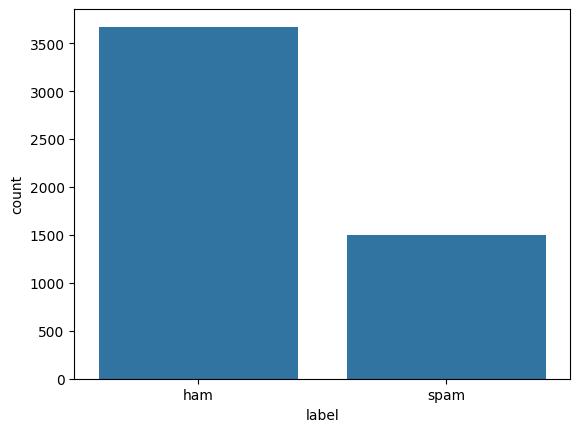

In [4]:
sns.countplot(x="label",data = data)

We have an imbalanceed data so we will first balance it

In [5]:
ham_msg = data[data["label"] == "ham"]
spam_msg = data[data["label"] == "spam"]

#Downsampling Ham to the number of spam
balanced_ham = ham_msg.sample(n = len(spam_msg), random_state = 42)
balanced_data = pd.concat([spam_msg, balanced_ham]).reset_index(drop= True)



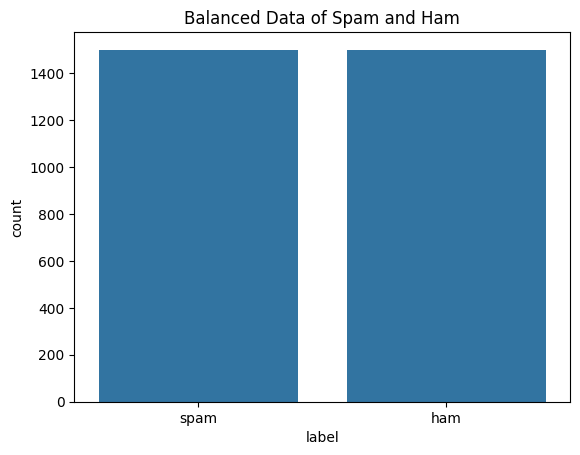

In [6]:
#Visualizing the balanced data
sns.countplot(x = "label", data = balanced_data)
plt.title("Balanced Data of Spam and Ham")
plt.show()

In [7]:
balanced_data["text"] = balanced_data["text"].str.replace("Subject:","")
punctuation_list = string.punctuation

def remove_punctuation(text):
  temp = str.maketrans("","",punctuation_list)
  return text.translate(temp)

balanced_data["text"] = balanced_data["text"].apply(lambda x: remove_punctuation(x))
balanced_data.head()


,Unnamed: 0,label,text,label_num
0,4685,spam,photoshop windows office cheap main trend...,1
1,4185,spam,looking for medication we re the best sourc...,1
2,4922,spam,vocable rnd word asceticism\r\nvcsc brand ...,1
3,3799,spam,report 01405 \r\nwffur attion brom est inst s...,1
4,3948,spam,vic odin n ow\r\nberne hotbox carnal bride ...,1


In [8]:
#Removing stopwords for better processing
def remove_stopwords(text):
  stop_words = stopwords.words("english")
  imp_words = []
  for word in text.split():
    word = word.lower()
    if word not in stop_words:
      imp_words.append(word)
  return " ".join(imp_words)


In [9]:
balanced_data["text"] = balanced_data["text"].apply(lambda x : remove_stopwords(x))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,4685,spam,photoshop windows office cheap main trending a...,1
1,4185,spam,looking medication best source difficult make ...,1
2,4922,spam,vocable rnd word asceticism vcsc brand new sto...,1
3,3799,spam,report 01405 wffur attion brom est inst siupie...,1
4,3948,spam,vic odin n ow berne hotbox carnal bride cutwor...,1


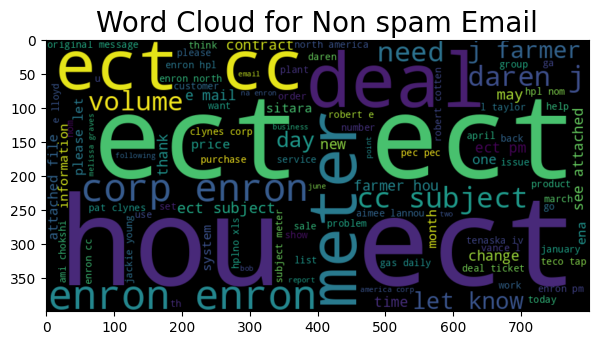

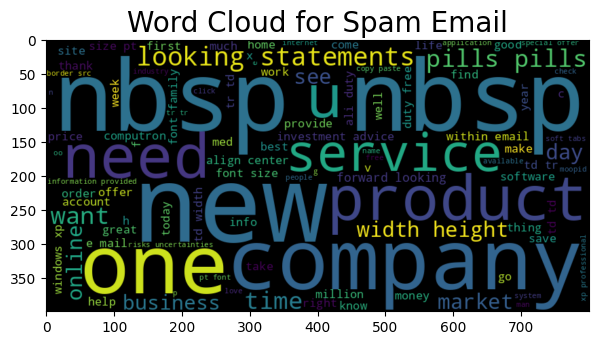

In [10]:
def plot_word_cloud(data,typ):
  email_corpus = " ".join(data["text"])
  wc = WordCloud(background_color="black", max_words = 100, width = 800, height = 400).generate(email_corpus)

  plt.figure(figsize=(7,7))
  plt.imshow(wc, interpolation = "bilinear")
  plt.title(f"Word Cloud for {typ} Email", fontsize = 20)
  plt.show()

plot_word_cloud(balanced_data[balanced_data["label"] == "ham"], typ = "Non spam")
plot_word_cloud(balanced_data[balanced_data["label"] == "spam"], typ = "Spam")

Tokenization and Padding

In [23]:
train_X,test_X, train_y,test_y = train_test_split(balanced_data["text"], balanced_data["label"], test_size = 0.2, random_state=42)
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

max_len = 100
train_sequences = pad_sequences(train_sequences, maxlen = max_len, padding = "post", truncating = "post")
test_sequences = pad_sequences(test_sequences, maxlen = max_len, padding = "post", truncating =  "post" )

train_y =  (train_y == "spam").astype(int)
test_y = (test_y == "spam").astype(int)

In [24]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32, input_length=max_len),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer='adam',
    metrics=['accuracy']
)

print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [25]:
es = EarlyStopping(patience = 3, monitor = "val_accuracy", restore_best_weights = True)
lr = ReduceLROnPlateau(patience = 3, monitor = "val_loss", factor = 0.5, verbose = 0)
history = model.fit(
    train_sequences,train_y,
    validation_data = (test_sequences, test_y),
    epochs = 20,
    batch_size =32,
    callbacks = [es,lr]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.5130 - loss: 0.6918 - val_accuracy: 0.9467 - val_loss: 0.4649 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9558 - loss: 0.2717 - val_accuracy: 0.9500 - val_loss: 0.2002 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9732 - loss: 0.1240 - val_accuracy: 0.9517 - val_loss: 0.1981 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.9681 - loss: 0.1405 - val_accuracy: 0.9483 - val_loss: 0.2172 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.9782 - loss: 0.1043 - val_accuracy: 0.9467 - val_loss: 0.2224 - learning_rate: 0.0010
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.9827 - loss: 0.0877 - val_accuracy: 0.9450 - val_loss: 0.2206 - learning_rate: 0.0010


In [26]:
test_loss, test_accuracy = model.evaluate(test_sequences, test_y)
print(f"Loss: {test_loss} \nAccuracy: {test_accuracy}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9518 - loss: 0.1997
Loss: 0.1980741024017334 
Accuracy: 0.9516666531562805


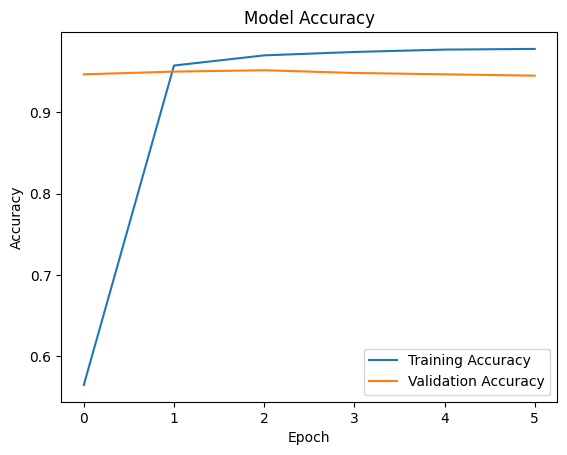

In [27]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()